✅ 데이터 분할 완료: 학습용 467건, 테스트용 117건

🌲 AI 모델(랜덤 포레스트)이 과거 패턴을 학습하고 있습니다...
📊 수치 예측 설명력 (R² Score): 70.35%

🚨 조류경보제 7일 전 예측 적중률: 89.74%



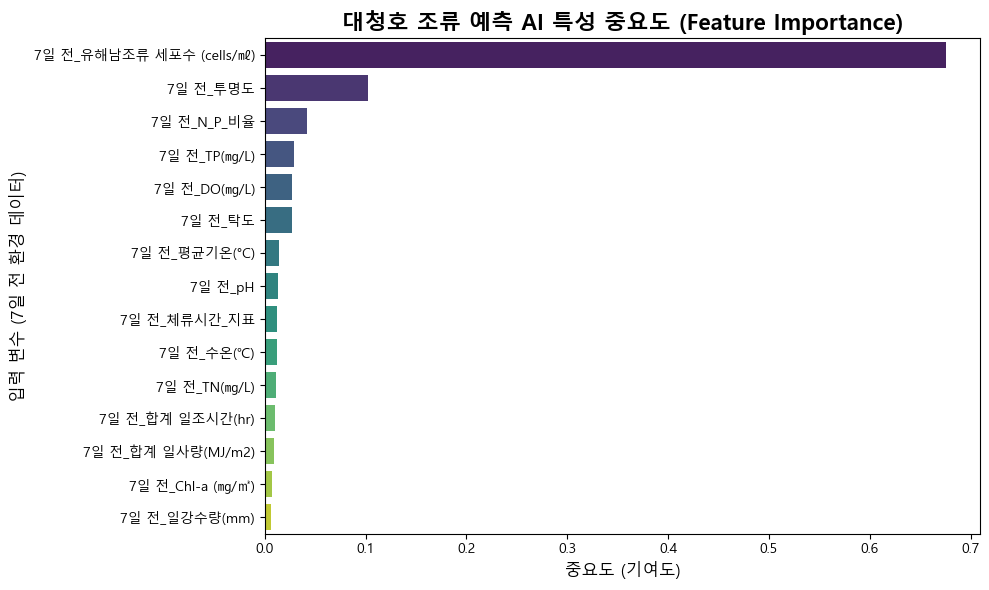

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 전처리 완료된 학습용 데이터 로드
df = pd.read_csv('대청호_ML_학습용_최종_전처리완료.csv')

# 3. X(원인 변수), y(정답 변수) 분리
target_col = '유해남조류 세포수 (cells/㎖)'
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Train / Test 데이터 분할 (과거 80% 학습, 최신 20% 테스트)
# 🚨 시계열 데이터이므로 랜덤으로 섞지 않고(shuffle=False) 순서대로 자릅니다!
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ 데이터 분할 완료: 학습용 {len(X_train)}건, 테스트용 {len(X_test)}건\n")

# 5. 모델 학습 (Random Forest Regressor)
print("🌲 AI 모델(랜덤 포레스트)이 과거 패턴을 학습하고 있습니다...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. 예측 및 수치 평가 (R² Score)
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"📊 수치 예측 설명력 (R² Score): {r2 * 100:.2f}%\n")

# 7. [필살기] 조류경보제 단계 적중률(Accuracy) 계산
def get_algae_alert_level(cells):
    if cells < 1000: return '평상시'
    elif cells < 10000: return '관심'
    elif cells < 1000000: return '경계'
    else: return '대발생'

# 실제 정답과 AI의 예측값을 모두 4단계 경보 신호등으로 변환
y_test_levels = [get_algae_alert_level(val) for val in y_test]
y_pred_levels = [get_algae_alert_level(val) for val in y_pred]

accuracy = accuracy_score(y_test_levels, y_pred_levels)
print(f"🚨 조류경보제 7일 전 예측 적중률: {accuracy * 100:.2f}%\n")

# 8. 특성 중요도(Feature Importance) 시각화
importance = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('대청호 조류 예측 AI 특성 중요도 (Feature Importance)', fontsize=16, fontweight='bold')
plt.xlabel('중요도 (기여도)', fontsize=12)
plt.ylabel('입력 변수 (7일 전 환경 데이터)', fontsize=12)
plt.tight_layout()
plt.show()

🌲 순수 환경 변수만으로 AI 모델을 학습합니다...
📊 수치 예측 설명력 (R² Score): 39.58%
🚨 조류경보제 7일 전 예측 적중률: 74.36%



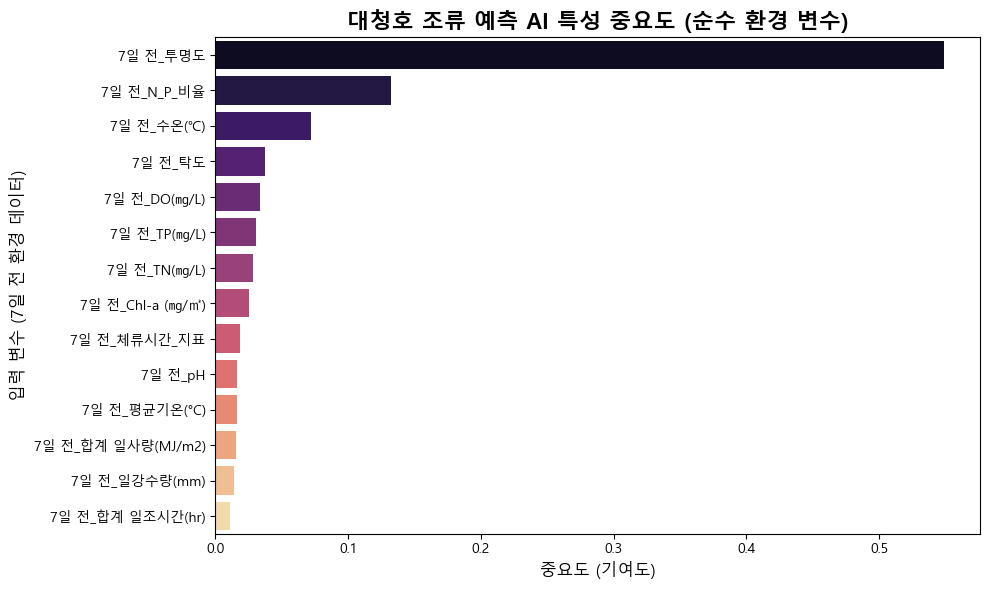

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('대청호_ML_학습용_최종_전처리완료.csv')

target_col = '유해남조류 세포수 (cells/㎖)'
# 🚨 핵심: 예측을 게으르게 만드는 '7일 전_유해남조류 세포수'를 입력 변수(X)에서 아예 빼버림!
seed_col = '7일 전_유해남조류 세포수 (cells/㎖)'

X = df.drop(columns=[target_col, seed_col])
y = df[target_col]

# 시계열 순서대로 80% 학습, 20% 테스트 분할
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("🌲 순수 환경 변수만으로 AI 모델을 학습합니다...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 평가
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"📊 수치 예측 설명력 (R² Score): {r2 * 100:.2f}%")

def get_algae_alert_level(cells):
    if cells < 1000: return '평상시'
    elif cells < 10000: return '관심'
    elif cells < 1000000: return '경계'
    else: return '대발생'

y_test_levels = [get_algae_alert_level(val) for val in y_test]
y_pred_levels = [get_algae_alert_level(val) for val in y_pred]

accuracy = accuracy_score(y_test_levels, y_pred_levels)
print(f"🚨 조류경보제 7일 전 예측 적중률: {accuracy * 100:.2f}%\n")

# 특성 중요도 그래프 출력
importance = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('대청호 조류 예측 AI 특성 중요도 (순수 환경 변수)', fontsize=16, fontweight='bold')
plt.xlabel('중요도 (기여도)', fontsize=12)
plt.ylabel('입력 변수 (7일 전 환경 데이터)', fontsize=12)
plt.tight_layout()
plt.show()

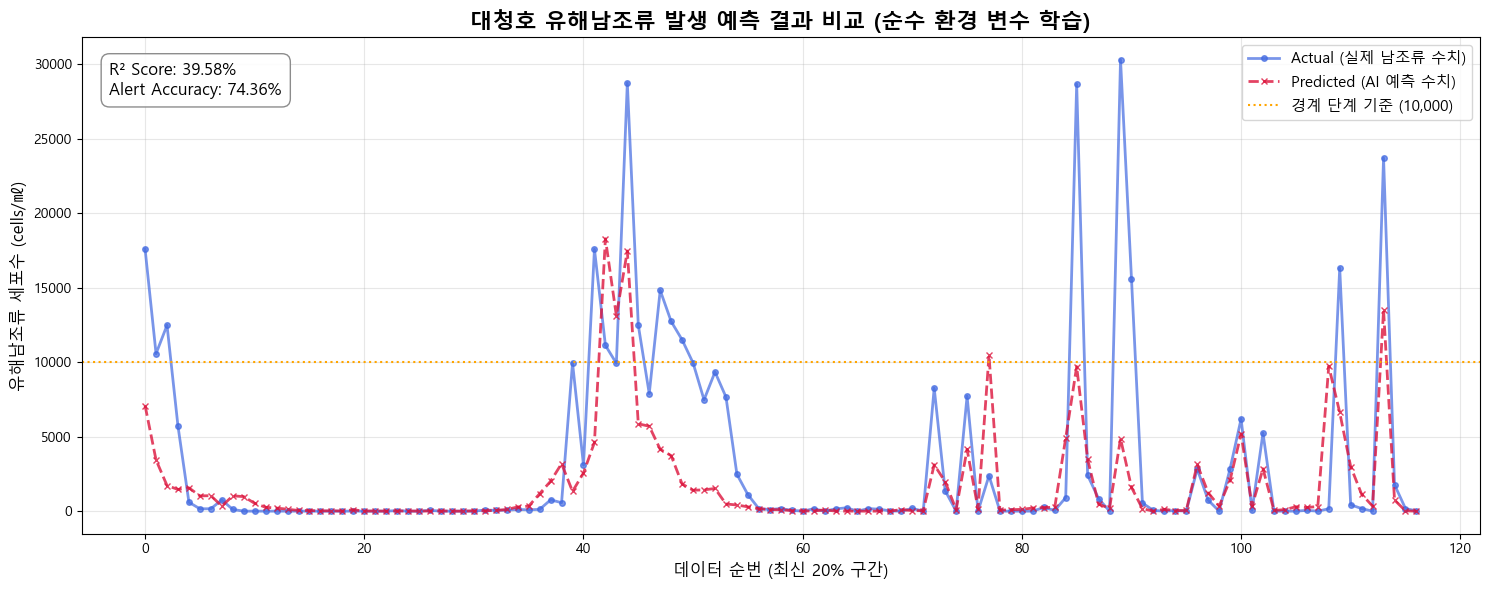

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (🚨 아까 성공했던 '최종 전처리 완료' 파일명으로 수정!)
# 파일명이 다르다면 근서가 가지고 있는 찐 최종 파일명으로 바꿔줘!
df = pd.read_csv('대청호_ML_학습용_최종_전처리완료.csv')

# 혹시 '조사일' 같은 날짜 글자 데이터가 남아있으면 AI가 에러를 뱉으니 미리 제거
if '조사일' in df.columns:
    df = df.drop(columns=['조사일'])

# 3. X(원인), y(결과) 분리 및 과거 남조류(컨닝페이퍼) 제거!
target_col = '유해남조류 세포수 (cells/㎖)'
seed_col = '7일 전_유해남조류 세포수 (cells/㎖)' # 🚨 이것도 아까 성공했던 컬럼명으로 롤백!

X = df.drop(columns=[target_col, seed_col])
y = df[target_col]

# 4. 시계열 순서대로 80% 학습, 20% 테스트 분할
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 5. 모델 학습 (순수 환경 변수만으로 학습)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. 예측 및 성능 평가 (R² 및 적중률 계산)
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

def get_algae_alert_level(cells):
    if cells < 1000: return '평상시'
    elif cells < 10000: return '관심'
    elif cells < 1000000: return '경계'
    else: return '대발생'

y_test_levels = [get_algae_alert_level(val) for val in y_test]
y_pred_levels = [get_algae_alert_level(val) for val in y_pred]
accuracy = accuracy_score(y_test_levels, y_pred_levels)

# ==============================================================
# 📉 7. 시각화 (R² 및 적중률 텍스트 박스 포함!)
# ==============================================================
plt.figure(figsize=(15, 6))

# 실제값과 예측값 그리기
plt.plot(y_test.values, label='Actual (실제 남조류 수치)', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.7)
plt.plot(y_pred, label='Predicted (AI 예측 수치)', color='crimson', linewidth=2, linestyle='--', marker='x', markersize=4, alpha=0.8)

# 조류경보제 기준선 추가
plt.axhline(10000, color='orange', linestyle=':', label='경계 단계 기준 (10,000)')

# 텍스트 박스 추가 (그래프 안쪽 좌측 상단)
stats_text = f'R² Score: {r2*100:.2f}%\nAlert Accuracy: {accuracy*100:.2f}%'
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

# 그래프 꾸미기
plt.title('대청호 유해남조류 발생 예측 결과 비교 (순수 환경 변수 학습)', fontsize=16, fontweight='bold')
plt.xlabel('데이터 순번 (최신 20% 구간)', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

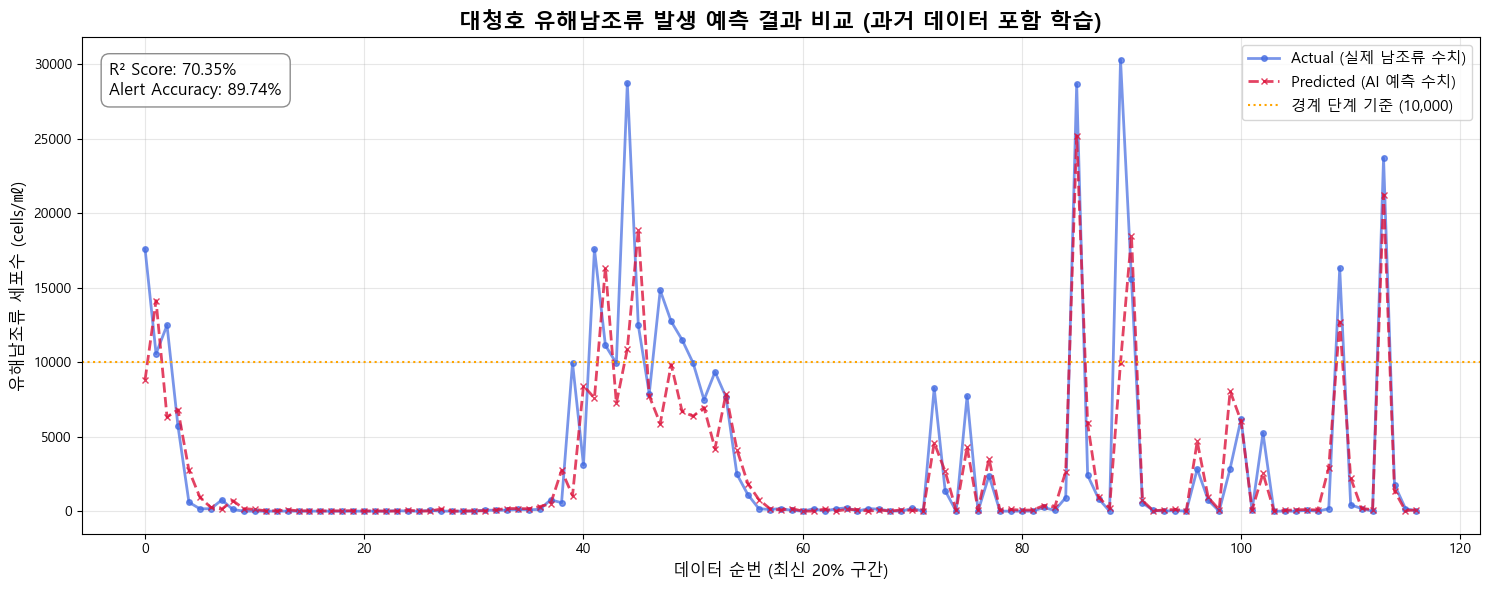

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('대청호_ML_학습용_최종_전처리완료.csv')

if '조사일' in df.columns:
    df = df.drop(columns=['조사일'])

target_col = '유해남조류 세포수 (cells/㎖)'
seed_col = '7일 전_유해남조류 세포수 (cells/㎖)' 

# 🌟 여기가 핵심 변경점! seed_col(과거 남조류)을 지우지 않고 AI한테 그대로 줍니다.
X = df.drop(columns=[target_col]) 
y = df[target_col]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

def get_algae_alert_level(cells):
    if cells < 1000: return '평상시'
    elif cells < 10000: return '관심'
    elif cells < 1000000: return '경계'
    else: return '대발생'

y_test_levels = [get_algae_alert_level(val) for val in y_test]
y_pred_levels = [get_algae_alert_level(val) for val in y_pred]
accuracy = accuracy_score(y_test_levels, y_pred_levels)

# ==============================================================
# 📉 시각화 
# ==============================================================
plt.figure(figsize=(15, 6))

plt.plot(y_test.values, label='Actual (실제 남조류 수치)', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.7)
plt.plot(y_pred, label='Predicted (AI 예측 수치)', color='crimson', linewidth=2, linestyle='--', marker='x', markersize=4, alpha=0.8)

plt.axhline(10000, color='orange', linestyle=':', label='경계 단계 기준 (10,000)')

stats_text = f'R² Score: {r2*100:.2f}%\nAlert Accuracy: {accuracy*100:.2f}%'
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

# 🌟 제목도 알아보기 쉽게 바꿨어!
plt.title('대청호 유해남조류 발생 예측 결과 비교 (과거 데이터 포함 학습)', fontsize=16, fontweight='bold')
plt.xlabel('데이터 순번 (최신 20% 구간)', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()